<a href="https://colab.research.google.com/github/Dworlock11/Exoplanet-Prediction-and-Analysis/blob/main/Exoplanet%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Overview**

This project builds machine learning models to predict exoplanet type and planet mass using a real-world exoplanet dataset. Multiple models, including logistic/linear regression, decision trees, and random forests, are trained with hyperparameter tuning and cross-validation to ensure robust performance. Feature importance is analyzed to identify the most influential factors driving predictions. The workflow emphasizes both predictive accuracy and interpretability, culminating in the selection of the best model for each task. This project demonstrates a comprehensive, production-ready approach to applied machine learning on scientific data.

# **Import Statements**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (make_scorer, confusion_matrix, ConfusionMatrixDisplay, classification_report, mean_absolute_error,
                             root_mean_squared_error)
from sklearn.inspection import permutation_importance
from sklearn.exceptions import ConvergenceWarning
from warnings import simplefilter
from preprocessing import remove_cols, log_space, huber_loss, mini_terran, mass_dist, radius_dist, remove_null_entries
from modeling import (data_spliting, optimizing_training_predicting, classification_evaluation, feature_importance, regression_scoring,
                      regression_plots)

# **Exploratory Data Analysis and Preprocessing**

The data from the exoplanet catlog contained in the Excel sheet is read into a DataFrame.

In [2]:
df = pd.read_excel("Exoplanet Catalog.xlsx")
pd.set_option("display.max_columns", None)
df

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,P_PERIOD,P_PERIOD_ERROR_MIN,P_PERIOD_ERROR_MAX,P_SEMI_MAJOR_AXIS,P_SEMI_MAJOR_AXIS_ERROR_MIN,P_SEMI_MAJOR_AXIS_ERROR_MAX,P_ECCENTRICITY,P_ECCENTRICITY_ERROR_MIN,P_ECCENTRICITY_ERROR_MAX,P_INCLINATION,P_INCLINATION_ERROR_MIN,P_INCLINATION_ERROR_MAX,P_OMEGA,P_OMEGA_ERROR_MIN,P_OMEGA_ERROR_MAX,P_TPERI,P_TPERI_ERROR_MIN,P_TPERI_ERROR_MAX,P_ANGULAR_DISTANCE,P_IMPACT_PARAMETER,P_IMPACT_PARAMETER_ERROR_MIN,P_IMPACT_PARAMETER_ERROR_MAX,P_TEMP_MEASURED,P_GEO_ALBEDO,P_GEO_ALBEDO_ERROR_MIN,P_GEO_ALBEDO_ERROR_MAX,P_DETECTION,P_DETECTION_MASS,P_DETECTION_RADIUS,P_ALT_NAMES,P_ATMOSPHERE,S_NAME,S_RA,S_DEC,S_MAG,S_DISTANCE,S_DISTANCE_ERROR_MIN,S_DISTANCE_ERROR_MAX,S_METALLICITY,S_METALLICITY_ERROR_MIN,S_METALLICITY_ERROR_MAX,S_MASS,S_MASS_ERROR_MIN,S_MASS_ERROR_MAX,S_RADIUS,S_RADIUS_ERROR_MIN,S_RADIUS_ERROR_MAX,S_TYPE,S_AGE,S_AGE_ERROR_MIN,S_AGE_ERROR_MAX,S_TEMPERATURE,S_TEMPERATURE_ERROR_MIN,S_TEMPERATURE_ERROR_MAX,S_DISC,S_MAGNETIC_FIELD,S_LOG_G,S_ALT_NAMES,P_ESCAPE,P_POTENTIAL,P_GRAVITY,P_DENSITY,P_HILL_SPHERE,P_DISTANCE,P_PERIASTRON,P_APASTRON,P_DISTANCE_EFF,P_FLUX,P_FLUX_MIN,P_FLUX_MAX,P_TEMP_EQUIL,P_TEMP_EQUIL_MIN,P_TEMP_EQUIL_MAX,P_TYPE,S_RADIUS_EST,S_TYPE_TEMP,S_RA_H,S_RA_T,S_DEC_T,S_LUMINOSITY,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_HZ_CON0_MIN,S_HZ_CON0_MAX,S_HZ_CON1_MIN,S_HZ_CON1_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007.0,2014-05-14,326.030000,-0.320,0.320,1.29000,-0.050,0.050,0.231,-0.005,0.005,NaN,NaN,NaN,94.8,-1.5,1.5,2452899.6,-1.6,1.6,13.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Radial Velocity,NaN,NaN,NaN,NaN,11 Com,185.179280,17.792868,4.740,93.37,-1.92,1.92,-0.35,-0.09,0.09,2.70,-0.300,0.300,19.000000,-2.000,2.000,K0 III,NaN,NaN,NaN,4742.0,-100.0,100.0,NaN,NaN,2.31,"HD 107383, HIP 60202",NaN,NaN,NaN,NaN,0.130671,1.324418,0.99201,1.58799,1.298759,101.011410,64.855456,166.191940,799.44963,722.98875,914.73942,Jovian,19.000000,K,12.345286,12 20 43.0286,+17 47 34.3248,163.546800,10.132812,24.763411,12.834754,23.477907,13.586847,23.477907,12.390643,23.477907,34.529063,0.476460,0.642400,0.0,0.0,Hot,0.0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.863300,1.29000
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009.0,2018-09-06,516.219970,-3.200,3.200,1.53000,-0.070,0.070,0.080,-0.030,0.030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Radial Velocity,NaN,NaN,NaN,NaN,11 UMi,229.274540,71.823898,5.016,125.72,-1.97,1.97,-0.02,NaN,NaN,2.78,-0.690,0.690,29.790000,-2.840,2.840,K4 III,NaN,NaN,NaN,4213.0,-46.0,46.0,NaN,NaN,1.93,"HD 136726, HIP 74793",NaN,NaN,NaN,NaN,0.167551,1.534896,1.40760,1.65240,1.531227,107.351180,91.741348,126.426170,819.07569,788.47184,854.28770,Jovian,29.790000,K,15.284970,15 17 05.8915,+71 49 26.0328,250.492940,12.770059,31.984271,16.175280,30.323783,17.134143,30.323783,15.615215,30.323783,42.732816,0.193891,0.648683,0.0,0.0,Hot,0.0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.784800,1.53000
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008.0,2014-05-14,185.840000,-0.230,0.230,0.83000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,2452861.4,-1.5,1.5,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Radial Velocity,NaN,NaN,NaN,NaN,14 And,352.822570,39.236198,5.227,75.59,-0.71,0.71,-0.24,-0.03,0.03,2.20,-0.200,0.100,11.000000,-1.000,1.000,G8 III,NaN,NaN,NaN,4813.0,-20.0,20.0,NaN,NaN,2.63,"HD 221345, HIP 116076",NaN,NaN,NaN,NaN,0.073485,0.830000,0.83000,0.83000,0.830000,84.446427,84.446427,84.446427,772.30746,772.30746,772.30746,Jovian,11.000000,G,23.521506,23 31 17.4215,+39 14 10.3128,58.175144,6.025230,14.680087,7.631867,13.918028,8.078404,13.918028,7.367780,13.918028,20.593611,0.502752,0.600010,0.0,0.0,Hot,0.0,0.081917,Andromeda,And,And

Before the data can be used for model development, it needs to be cleaned and analyzed. Firstly, as many of the columns from the dataset contain many null entries, it is best to simply remove them. Therefore, all columns where more than a quarter of the entries are null are removed. Additional feature selection is also conducted, as many of the features are unhelpful for model training, are copies of one another, are highly correlated with one another, or have far too many different values. Below are the numbers of unique values for each categorical feature, with many being removed.

In [3]:
df = remove_cols(df)

Value count per feature:

P_DETECTION - 10
P_TYPE - 6
S_TYPE_TEMP - 7
S_RA_T - 3010
S_DEC_T - 3010
P_TYPE_TEMP - 3
S_CONSTELLATION - 88
S_CONSTELLATION_ENG - 88


To determine the appropriate imputing method for the numerical data, the data is checked for the skew of each feature. Since the features are heavily skewed overall, the median will be chosen. Below is the skew of each column.

In [4]:
np.abs(df.skew(axis=0, numeric_only=True, skipna=True)).sort_values(ascending=False)

,0
P_PERIOD,62.170001
P_FLUX,45.699102
S_MASS_ERROR_MAX,45.649624
S_ABIO_ZONE,39.242821
S_RADIUS_ERROR_MIN,32.113850
S_RADIUS_ERROR_MAX,31.053663
P_PERIASTRON,28.463444
P_SEMI_MAJOR_AXIS_EST,28.395487
P_DISTANCE_EFF,28.376942
P_DISTANCE,28.337572


The distribution of the exoplanet type column is observed.

In [5]:
df["P_TYPE"].value_counts()

,count
P_TYPE,
Jovian,1302
Superterran,1099
Neptunian,898
Terran,673
Subterran,58
Miniterran,1


There is only a single Miniterran planet in the dataset and thus cannot be split between a training and test set. However, if the Miniterran in the data were to have a radius close to that of Subterrans, it would be appropriate to mask it as one, since, astronomically speaking, it wouldn't be too different from the smallest Subterrans discovered. Indeed, the radius is around 0.33 times that of Earth, which isn't too far in value from the smallest Subterran in the dataset. Therefore, the planet is masked as one. After masking, no Miniterrans remain, as shown in the following value count.

In [6]:
df = mini_terran(df)

df["P_TYPE"].value_counts()

Miniterran mass: 0.334
Smallest Subterran mass: 0.404


,count
P_TYPE,
Jovian,1302
Superterran,1099
Neptunian,898
Terran,673
Subterran,59


Exoplanet mass and radius are two features that will almost certainly be strong predictors of exoplanet type. From domain knowledge, one can asume that Jovian planets will be more massive and large than Terrans, for example. Similarily, radius will most likely be a strong predictor of mass for the regression models. Thus, the distributions of these two key features are observed.

In [7]:
df["P_MASS_EST"].describe()

,P_MASS_EST
count,4048.000000
mean,323.089993
std,965.084290
min,0.000000
25%,3.628101
50%,7.815324
75%,149.379160
max,17668.059000


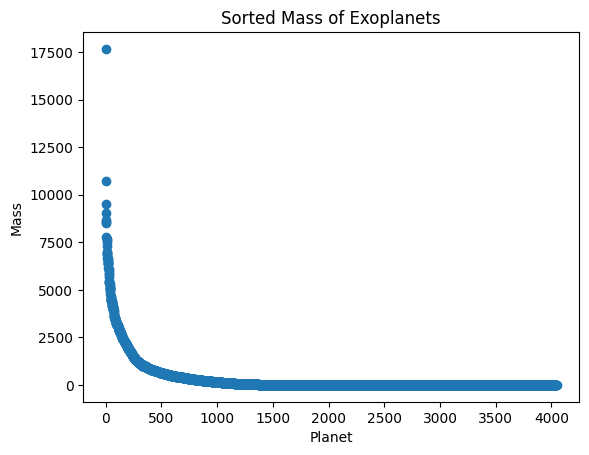

In [8]:
mass_dist(df)

In [9]:
df["P_RADIUS_EST"].describe()

,P_RADIUS_EST
count,4048.000000
mean,5.588647
std,5.392733
min,0.000000
25%,1.703920
50%,2.667980
75%,11.770500
max,77.349000


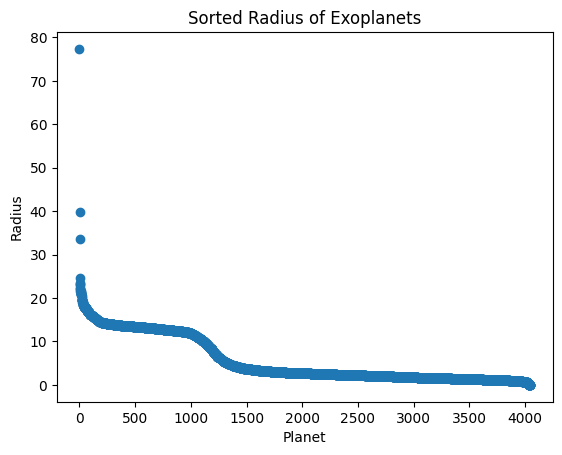

In [10]:
radius_dist(df)

Some insights can be observed:
*   A minority of exoplanets is significantly more massive and greater in size than the rest. Linear models will likely strugle to capture such nonlinear patterns. Therefore, it would be appropriate to perform a log transformation on the mass and radius features to make those models more robust.
*   There will likely be a noticible difference between the root mean squared error (RMSE) and mean absolute error (MAE) scores when evaluating the models during the regression stage, since RMSE is more sensitive to outliers.
*   Huber loss will be used for hyperparameter tuning and permutation importance in order to balance the majority of small planets with the minority of massive ones.
*   It's not clear what exactly it means for a planet to have a mass of 0.0. Such entries will be removed from the dataset.

In [11]:
huber_scorer = make_scorer(huber_loss, greater_is_better=False, delta=1.0)

df = df[df["P_MASS_EST"] != 0.0]

df = log_space(df)

Finally, all rows where the target value is null (if any) are removed to prevent errors.

In [12]:
df = remove_null_entries(df, "P_TYPE")
df = remove_null_entries(df, "Log_Mass")

Number of null values in P_TYPE: 1
Number of null values after removal: 0
Number of null values in Log_Mass: 0
Number of null values after removal: 0


Predictions can be made regarding model performance prior to training. Despite the log transformation of the mass and radius columns, the linear models might still capture the nonlinear distributions of those columns more poorly compared to the tree-based models, since the latter are more flexible in such cases. As a result, I expect the tree-based models to perform better.

# **Exoplanet Type Prediction**

The classification models will be trained first. The data is split into the training and testing data. The target is stratified by the exoplanet type to make sure that a proportional number of each type of planet is present in both the training set and the test set.

In [13]:
X, y, X_train, X_test, y_train, y_test, num_features, cat_features, num_col_names, cat_col_names = data_spliting(
    df, stratify=True, target="P_TYPE")

## Logistic Regression

The logistic regression model will be developed first. The data pipeline is created, including data imputing, standardizing, and encoding. KFolds object is created for cross-validation. Additionally, the parameter distribution for the hyperparameter C is created to ensure robust regularization.

In [14]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

linear_cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", feature_name_combiner="concat"))
])

log_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

log_pipe = Pipeline([
    ("log_preprocessor", log_preprocessor),
    ("log_reg", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=300
    ))
])

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=9)

param_dist = {
    "log_reg__C": np.logspace(-3, 3, 15),
}

The hyperparameter is tuned, the model is fitted to the data, and the target is predicted. The models perform well overall with little variation between folds.

In [15]:
best_model, y_pred = optimizing_training_predicting(log_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

C : 372.7593720314938

Best CV Score: 0.9702 ± 0.0057


The model is evaluated with a classification report, depicting useful metrics such as accuracy and the F1 score. Additionally, a confusion matrix is generated to illustrate these findings. The model performs very well overall, with most metrics being greater than 0.90.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.98      0.97      0.97       260
   Neptunian       0.94      0.93      0.94       180
   Subterran       0.86      1.00      0.92        12
 Superterran       0.96      0.98      0.97       220
      Terran       0.99      0.98      0.98       135

    accuracy                           0.97       807
   macro avg       0.95      0.97      0.96       807
weighted avg       0.97      0.97      0.97       807

Confusion Matrix:



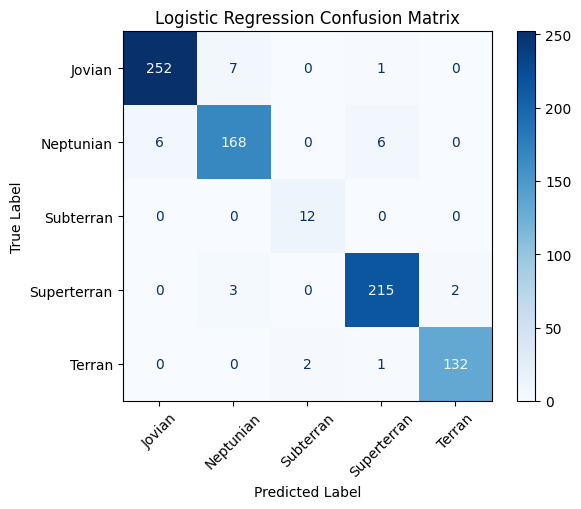

In [16]:
classification_evaluation(y_test, y_pred, model_name="Logistic Regression")

Permutation importance is used to find the importance of each feature. It will be used across all models for standardized results. The test set must be manually transformed with all preprocessing steps before implementing permutation to match the number of columns present after feature encoding. As predicted earlier, the most important features for predicting planet type are mass and radius.

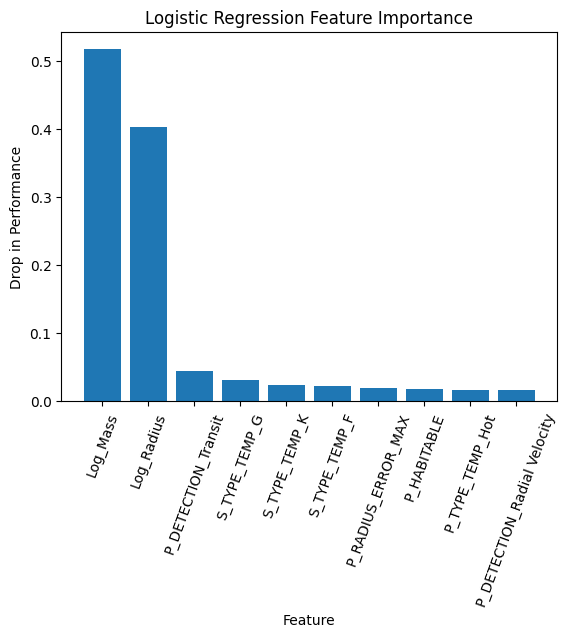

In [17]:
feature_importance(best_model, "log_preprocessor", "log_reg", X_test, y_test, None, model_name="Logistic Regression")

## Polynomial Logistic Regression

Now, a model of a higher degree is developed to see if there will be a significant difference.

A new preprocessor and pipeline are created to accomodate polynomial features.

In [18]:
# Build polynomial transformer
poly_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

# Combine transformers
poly_log_preprocessor = ColumnTransformer([
    ("poly_transformer", poly_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

poly_log_pipe = Pipeline([
    ("poly_log_preprocessor", poly_log_preprocessor),
    ("log_reg", LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=300
    ))
])

param_dist = {
    "log_reg__C": np.logspace(-3, 3, 15),
}

Hyperparameters are optimized, the model is fitted to the data, and the target is predicted.

In [19]:
best_model, y_pred = optimizing_training_predicting(poly_log_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

C : 1.0

Best CV Score: 0.9594 ± 0.0045


The model is evaluated with a classification report and a confusion matrix once again. The results are close to those from the regular logistic regression model, implying that increasing the polynomial degree doesn't help with predicting the target. Additionally, the model takes significantly longer to fit. Feature importance is ignored due to a lack of interpretability with the engineered polynomial features.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.98      0.96      0.97       260
   Neptunian       0.92      0.94      0.93       180
   Subterran       0.85      0.92      0.88        12
 Superterran       0.95      0.96      0.95       220
      Terran       0.97      0.96      0.96       135

    accuracy                           0.95       807
   macro avg       0.93      0.95      0.94       807
weighted avg       0.95      0.95      0.95       807

Confusion Matrix:



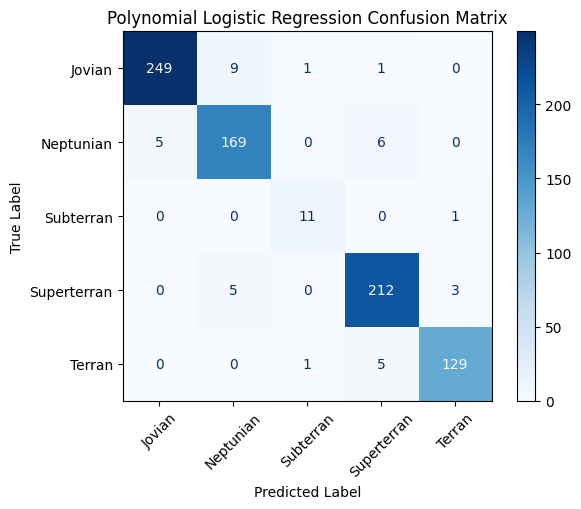

In [20]:
classification_evaluation(y_test, y_pred, model_name="Polynomial Logistic Regression")

## Decision Tree

Now, a decision tree model will be trained following the same process.

A new categorical transformer is created using ordinal encoding, which is suitable for tree-based models and better than one-hot encoding, since it doesn't create many sparse features. Key hyperparameters to avoid overfitting are chosen to be tuned.

In [21]:
# Create categorical transformer for tree models
tree_cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Combine transformers
tree_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("tree_cat_transformer", tree_cat_transformer, cat_col_names)
])

# Create pipeline
tree_clas_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("dec_tree", DecisionTreeClassifier())
])

# Parameter distribution
param_dist = {
    "dec_tree__max_depth": [None, 2, 5, 10, 20],
    "dec_tree__min_samples_split": [2, 5, 10, 20, 50],
    "dec_tree__min_samples_leaf": [1, 2, 5, 10, 20],
    "dec_tree__max_features": ["sqrt", "log2", None],
}

Optimization, training, and predicting are carried out.

In [22]:
best_model, y_pred = optimizing_training_predicting(tree_clas_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

min_samples_split : 2
min_samples_leaf : 5
max_features : None
max_depth : 10

Best CV Score: 0.9953 ± 0.0017


The model is tested and evaluated. The metrics are better overall compared to those from the linear models, as predicted before training.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.98      0.99      0.99       260
   Neptunian       0.98      0.97      0.98       180
   Subterran       1.00      1.00      1.00        12
 Superterran       1.00      1.00      1.00       220
      Terran       1.00      1.00      1.00       135

    accuracy                           0.99       807
   macro avg       0.99      0.99      0.99       807
weighted avg       0.99      0.99      0.99       807

Confusion Matrix:



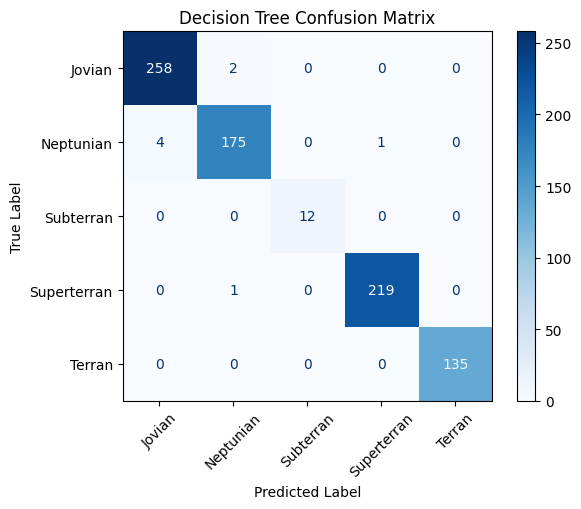

In [23]:
classification_evaluation(y_test, y_pred, "Decision Tree")

Permutation is once again used to discover feature importance, with the results being similar to before.

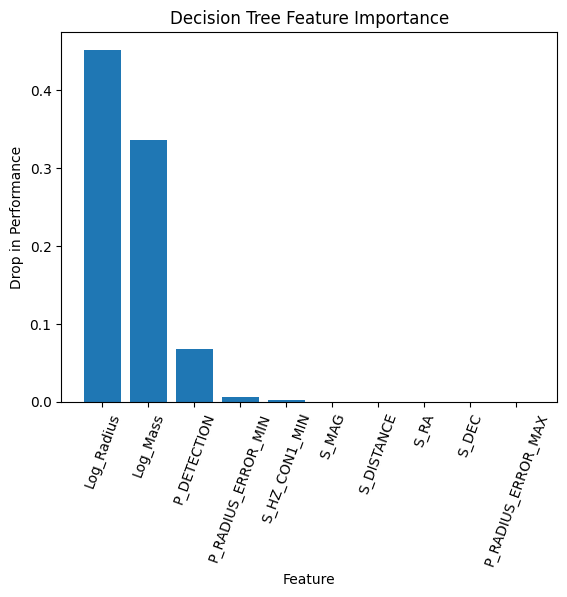

In [24]:
feature_importance(best_model, "tree_preprocessor", "dec_tree", X_test, y_test, None, "Decision Tree")

## Random Forest

Now, a random forest model will be trained.

The pipeline is created and hyperparameter tuning is implemented, testing ranges of values for the key hyperparameters.

In [25]:
forest_clas_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("rand_for", RandomForestClassifier())
])

param_dist = {
    "rand_for__n_estimators": [200, 400, 600, 800],
    "rand_for__max_depth": [None, 5, 10, 20, 40],
    "rand_for__min_samples_split": [2, 5, 10, 20],
    "rand_for__min_samples_leaf": [1, 2, 5, 10],
    "rand_for__max_features": ["sqrt", "log2", None],
    "rand_for__bootstrap": [True, False],
}

The model is trained and tuned hyperparameter values are shown.

In [26]:
best_model, y_pred = optimizing_training_predicting(forest_clas_pipe, param_dist, kf, None, X_train, y_train, X_test)

Best Parameters:

n_estimators : 600
min_samples_split : 5
min_samples_leaf : 2
max_features : None
max_depth : 40
bootstrap : True

Best CV Score: 0.9922 ± 0.0026


The model is again evaluated with a classification report and confusion matrix. The results are almost identical to those from the decision tree model, however, it required much more time to fit compared to that model.

Classification Report:

              precision    recall  f1-score   support

      Jovian       0.99      0.99      0.99       260
   Neptunian       0.98      0.98      0.98       180
   Subterran       1.00      1.00      1.00        12
 Superterran       1.00      1.00      1.00       220
      Terran       1.00      1.00      1.00       135

    accuracy                           0.99       807
   macro avg       0.99      0.99      0.99       807
weighted avg       0.99      0.99      0.99       807

Confusion Matrix:



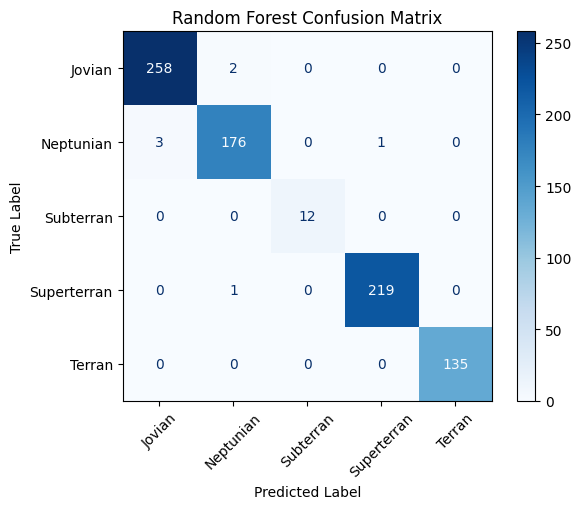

In [27]:
classification_evaluation(y_test, y_pred, "Random Forest")

Permutation is once again used to discover feature importance, with mass and radius once again standing out.

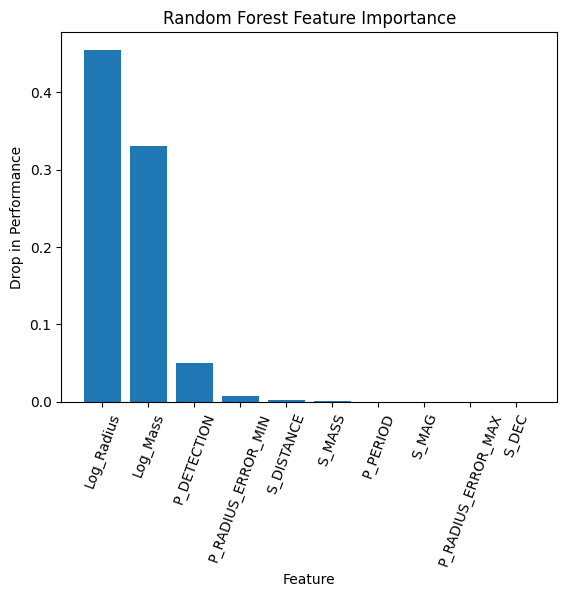

In [28]:
feature_importance(best_model, "tree_preprocessor", "rand_for", X_test, y_test, None, "Random Forest")

This concludes the development of the classfication models.

# **Exoplanet Mass Prediction**

Now, regression models will be developed to predict exoplanet mass. The data is split into training and testing data and the numerical and categorical features are identified.

In [29]:
X, y, X_train, X_test, y_train, y_test, num_features, cat_features, num_col_names, cat_col_names = data_spliting(df, stratify=False, target="Log_Mass")

## Linear Regression

A linear regression model is trained first as a baseline. The pipeline is created and the hyperparameter alpha will be tuned to allow for robust regularization.

In [30]:
# Combine transformers
ridge_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

ridge_pipe = Pipeline([
    ("ridge_preprocessor", ridge_preprocessor),
    ("ridge", Ridge())
])

kf = KFold(n_splits=5, shuffle=True, random_state=9)

param_dist = {
    "ridge__alpha": np.logspace(-4, 4)
}

Hyperparameter optimization, fitting, and predicting are conducted.

In [31]:
best_model, y_pred = optimizing_training_predicting(ridge_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

alpha : 1526.4179671752302

Best CV Score: -1225606926.1409 ± 2451213852.0994


RMSE and MAE are used to evaluate the model. The results are not promising. To understand why, the array of predicted values is analyzed along with the actual values.

In [32]:
regression_scoring(y_test, y_pred)

MAE factor  : 3.46×
RMSE factor : 42075888.96×


In [33]:
y_pred_se = pd.Series(y_pred)

y_pred_se.describe()

,0
count,807.000000
mean,1.561440
std,7.738931
min,0.114044
25%,0.679039
50%,0.987926
75%,2.091634
max,219.886057


In [34]:
y_test_se = y_test.reset_index(drop=True)

y_test_se.describe()

,Log_Mass
count,807.000000
mean,1.260273
std,1.007618
min,-1.719657
25%,0.578587
50%,0.874435
75%,2.090880
max,3.884029


There appears to be a major outlier present in the predicted values. This is further visible in a scatter plot of the actual and predicted values. It appears that one heavily inacurate prediction is causing the metrics to significantly worsen.

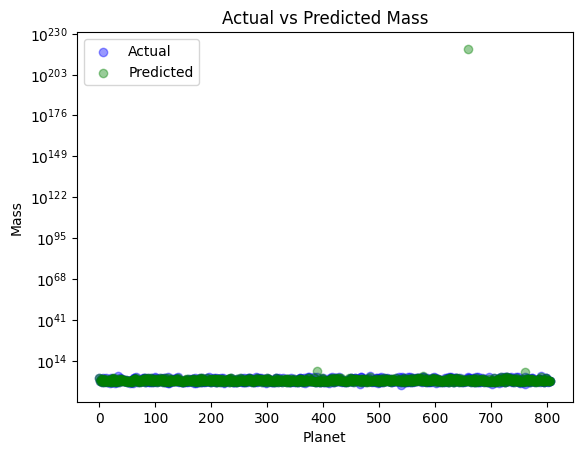

In [35]:
regression_plots(y_test, y_pred)

Feature importance is ignored, since, without good metrics, the results would not be helpful. Linear regression does not seem to be a good model for this task.

## Polynomial Linear Regression

Perhaps adding polynomial features will improve the results if the model will thus be able to better capture the mass column's distribution. Polynomial degrees 2 and 3 will be tested and compared to degree 1.

In [36]:
poly_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler())
])

poly_ridge_preprocessor = ColumnTransformer([
    ("poly_transformer", poly_transformer, num_col_names),
    ("linear_cat_transformer", linear_cat_transformer, cat_col_names)
])

poly_ridge_pipe = Pipeline([
    ("poly_ridge_preprocessor", poly_ridge_preprocessor),
    ("ridge", Ridge())
])

param_dist = {
    "poly_ridge_preprocessor__poly_transformer__poly__degree" : [2, 3],
    "ridge__alpha" : np.logspace(-4, 4)
}

Hyperparameters are tuned and the target is predicted as before.

In [37]:
best_model, y_pred = optimizing_training_predicting(poly_ridge_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

alpha : 719.6856730011514
poly_transformer__poly__degree : 2

Best CV Score: -311385972034046394368.0000 ± 622771944068092788736.0000


RMSE and MAE are used to evaluate the model. The results are significantly worse than even those from the model without polynomial features. In fact, the error is so large that an overflow error is triggered.

In [38]:
regression_scoring(y_test, y_pred)

MAE factor  : 1408025377286.61×
Overflow Error. The metrics were too large to be calculated.


The distributions of the actual and predicted values are observed again. As before, there is a single inacurate value bringing the model down.

In [39]:
y_pred_se = pd.Series(y_pred)

y_pred_se.describe()

,0
count,807.000000
mean,-10.689669
std,339.759479
min,-9650.492601
25%,0.561790
50%,0.916376
75%,2.271361
max,4.667302


In [40]:
y_test_se.describe()

,Log_Mass
count,807.000000
mean,1.260273
std,1.007618
min,-1.719657
25%,0.578587
50%,0.874435
75%,2.090880
max,3.884029


Feature importance is again ignored. With or without polynomial features, linear regression seems to be inadequate for predicting exoplanet mass.

## Decision Tree Regressor

Now, a decision tree is created, hopefully bearing better results. A suitable pipeline is created and hyperparamaters similar to those from the decision tree classifier model are chosen.

In [41]:
# Combine numerical and categorical transformers
tree_preprocessor = ColumnTransformer([
    ("num_transformer", num_transformer, num_col_names),
    ("tree_cat_transformer", tree_cat_transformer, cat_col_names)
])

tree_reg_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("dec_tree", DecisionTreeRegressor())
])

param_dist = {
    "dec_tree__max_depth": [None, 3, 5, 10, 20],
    "dec_tree__min_samples_split": [2, 5, 10, 20, 50],
    "dec_tree__min_samples_leaf": [1, 2, 5, 10, 20, 50],
    "dec_tree__max_features": [None, "sqrt", "log2"]
}

The model is trained and hyperparameter values are displayed. Note that the cross-validation scores are reported as negative values because scikit-learn maximizes the negative loss function.

In [42]:
best_model, y_pred = optimizing_training_predicting(tree_reg_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

min_samples_split : 50
min_samples_leaf : 2
max_features : None
max_depth : 20

Best CV Score: -0.0257 ± 0.0029


As before, RMSE and MAE are used to evaluate the model. The results point to a strong model. Real exoplanet masses often have 30-100% observational uncertainty, so the produced error factor from the model would be considered very good.

In [43]:
regression_scoring(y_test, y_pred)

MAE factor  : 1.24×
RMSE factor : 1.67×


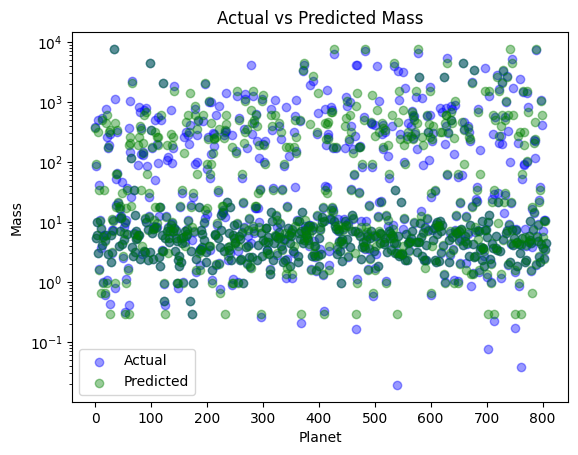

In [44]:
regression_plots(y_test, y_pred)

Permutation is used to find important features. By far the most important features are the planet's type and radius. These findings align with those from the classification models; planet type, mass, and radius are heavily correlated and thus act as strong predictors of each other.

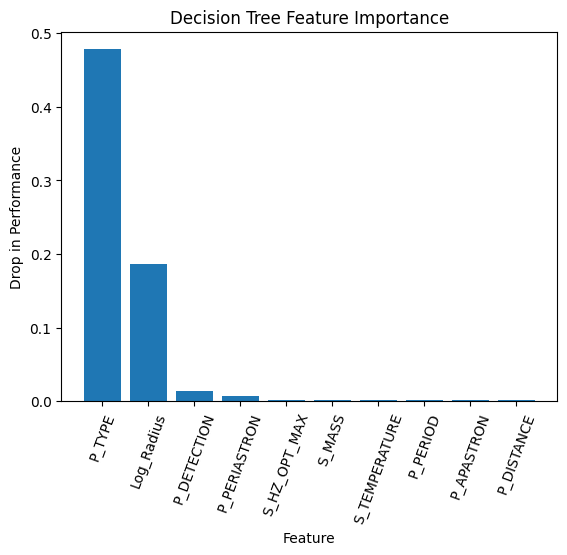

In [45]:
feature_importance(best_model, "tree_preprocessor", "dec_tree", X_test, y_test, huber_scorer, "Decision Tree")

## Random Forest Regressor

Perhaps a random forest will be even better for prediction. As usual, the pipeline is created.

In [46]:
forest_reg_pipe = Pipeline([
    ("tree_preprocessor", tree_preprocessor),
    ("rand_for", RandomForestRegressor())
])

param_dist = {
    "rand_for__n_estimators": [200, 300, 500, 800],
    "rand_for__max_depth": [None, 5, 10, 20, 40],
    "rand_for__min_samples_split": [2, 5, 10, 20],
    "rand_for__min_samples_leaf": [1, 2, 5, 10, 20],
    "rand_for__max_features": ["sqrt", "log2", None],
    "rand_for__bootstrap": [True, False]
}

Again, the model is trained and tuned hyperparameter values are shown.

In [47]:
best_model, y_pred = optimizing_training_predicting(forest_reg_pipe, param_dist, kf, huber_scorer, X_train, y_train, X_test)

Best Parameters:

n_estimators : 300
min_samples_split : 20
min_samples_leaf : 2
max_features : None
max_depth : 40
bootstrap : True

Best CV Score: -0.0203 ± 0.0026


RMSE and MAE are used to evaluate the model as before. The model performs slightly better than the decision tree model, but takes much more time to train. These results are similar to those from the classification tree-based models. A plot is generated as before to underscore these findings. The predicted and actual values are relatively close together, implying little error in prediction.

In [48]:
regression_scoring(y_test, y_pred)

MAE factor  : 1.20×
RMSE factor : 1.56×


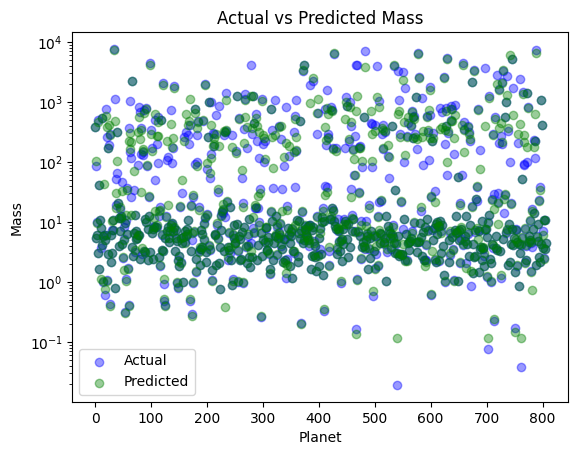

In [49]:
regression_plots(y_test, y_pred)

Feature importance is analyzed. The results are similar to those from the decision tree model.

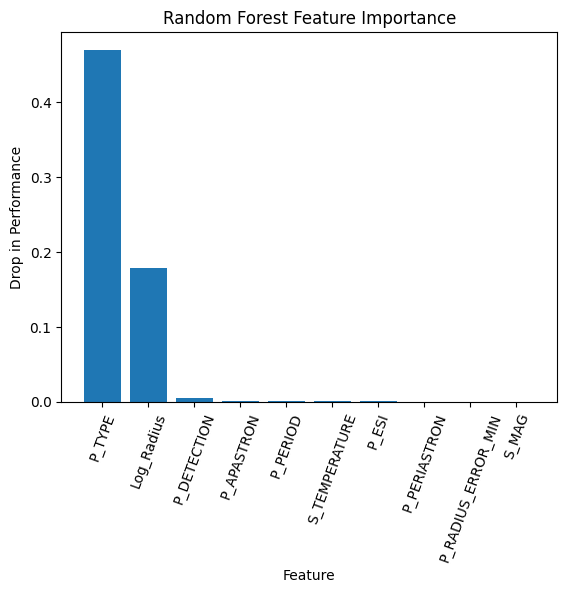

In [50]:
feature_importance(best_model, "tree_preprocessor", "rand_for", X_test, y_test, huber_scorer, "Random Forest")

# **Conclusion**

To conclude, important insights can be drawn from this analysis. Firstly, decision trees seem to be the all-around best models for both classification of exoplanet type and of mass. They provide generally better results than the linear models and take significantly longer to train than the random forest models. This is likely because decision trees are more flexible and robust than linear or logistic regression models, and random forests are seemingly unnecessarily thourough in avoiding overfitting. Another important discovery is that the most important features for classifying exoplanets were their radius and mass. The most important features for predicting a planet's mass were its type and radius. Therefore, exoplanet type, radius, and mass seem to be highly correlated. This has scientific precedent, as Jovian and Neptunian planets are known to have greater masses and sizes than Subterrans, for example. Therefore, this project uncovers a crucial relationship between these crucial exoplanet features which can be adroitly used in classifying and analyzing exoplanets.

# **Copyright**

The data used in this project was taken from the exoplanet catalog found here: https://www.kaggle.com/datasets/chandrimad31/phl-exoplanet-catalog?resource=download.

I claim no ownership of the data. All rights reserved to the rightful owners.